# Training the model for Prediction
In this notebook, we will explain how to train your model with the objective of capturing antigen specificity, which usually leads to nicely balanced embeddings between TCR and Gene Expression. For this, we optimize the network hyperparameters to capture specificity in the embedding. Specifically, the weighted F1-Score for predicting pMHC specificity via a kNN classifier is evaluated between the training (atlas) and validation (query) set. In this set-up, it is necessary that cell-level pMHC specificity information is available.

In [1]:
# comet-ml must be imported before torch and sklearn
import comet_ml
import scanpy as sc
import umap
import numpy as np

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

/ihome/ylee/yiz133/.conda/envs/mvTCR2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Preperation
First we load the data via the Scanpy API. This data is derived from the 10x Application note "A new way of exploring immunity". Please follow the notebook "preprocessing/10x_preprocessing.ipynb" (https://github.com/SchubertLab/mvTCR_reproducibility/tree/master/preprocessing) to derive this dataset. We will use the second donor downsampled to 3000 cells and only cells that have a binder with a sufficient amount of counts.

In [15]:
# Load
adata = sc.read_h5ad('merged_EAE.h5ad')
adata

AnnData object with n_obs × n_vars = 66525 × 2500
    obs: 'tissue', 'mouse_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clonotype', 'clonotype_size', 'alpha_len', 'beta_len'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'aa_to_id', 'chain_indices', 'clonotype', 'ir_dist_nt_identity'
    obsm: 'airr', 'alpha_seq', 'beta_seq', 'chain_indices'

In [16]:
adata.obs['set'] = adata.obs['mouse_id'].astype(str).apply(lambda x: 'test' if x.startswith('b') else 'train')

train_mask = adata.obs['set'] == 'train'
train_indices = adata.obs.index[train_mask]
n_val = int(0.2 * len(train_indices))
if n_val > 0:
    val_indices = np.random.choice(train_indices, size=n_val, replace=False)
    adata.obs.loc[val_indices, 'set'] = 'val'

In [17]:
adata.obs['set'].value_counts()

set
train    41200
test     15025
val      10300
Name: count, dtype: int64

Then we divide the data into training and validation data. Typically, a split of 20% validation data was used. The data is splitted to uniquely group 'clonotype' to either training or validation set.

## Defining the model parameters
We need to proivde the model a couple of parameters:
- study_name: Name for logging
- comet_workspace: we logged some of the experiments via Comet-ML. This gives you more information on the training process, but is not needed. We will therefore use None here. Otherwise, specifiy the workspace name of your Comet-ML project.
- model_name: assigns which model is used from (rna, tcr, moe, poe, concat). We will use the best performing moe.
- balanced_sample: oversample rare elements of this column. Recommended to use a column storing the clonotype to avoid overfitting.
- metadata: annotation to color the umaps when storing immediate results on Comet-ML. If no Comet-ML is used, pass an empty list
- model_path: path to store the trained models over multiple training runs
- n_epoch: amounts of epochs to train the model. For the paper we used 200 epochs. For showcasing however, we will reduce it to 5.

In [18]:
model_path = './saved_models/merged/DE2500_epoch50'
params_experiment = {
    'study_name': '10x_prediction',
    'comet_workspace': None, 
    'model_name': 'moe',
    'balanced_sampling': 'clonotype',
    'metadata': [],
    'save_path': model_path,
    'n_epochs':50,
}

## Defining Optimization parameters
For this dataset, we will optimize to predict properties (TCR specificity, in this case) via knn-Atlas-Query-Matching within the dataset. This usually leads to nicely balanced embeddings between TCR and GEX. However, it requieres the annotation of TCR specificity in the column <prediction_column>.

In [19]:
params_optimization = {
    'name': 'knn_prediction',
    'prediction_column': 'tissue',
}

## Calling the training functions
Finally, we need to specificy a couple of parameters for running the training. Training will be aborted either after \<timeout\> seconds or after having trained 3 models with 1 available GPU.

In [20]:
from mvtcr.models.model_selection import run_model_selection

timeout = (20*60)
n_samples = 1
n_gpus = 1
seed = 42
run_model_selection(adata, params_experiment, params_optimization, n_samples, timeout, n_gpus, sampler_seed=seed)

[I 2025-10-03 12:32:18,895] A new study created in RDB with name: 10x_prediction
100%|██████████| 50/50 [11:48<00:00, 14.18s/it]
[I 2025-10-03 12:44:08,909] Trial 0 finished with value: 0.9999029034831954 and parameters: {'dropout': 0.1, 'activation': 'linear', 'rna_hidden': 1500, 'hdim': 200, 'shared_hidden': 100, 'rna_num_layers': 1, 'tfmr_encoding_layers': 4, 'loss_weights_kl': 4.0428727350273357e-07, 'loss_weights_tcr': 0.034702669886504146, 'lr': 1.0994335574766187e-05, 'zdim': 50, 'tfmr_embedding_size': 16, 'tfmr_num_heads': 8, 'tfmr_dropout': 0.15000000000000002}. Best is trial 0 with value: 0.9999029034831954.


Study statistics:
  Number of finished trials: 1
  Number of pruned trials: 0
  Number of complete trials: 1
Best trial: 
  trial_0
  Value: 0.9999029034831954


### Optuna Dashboard
Optionally you can use Optuna Dashboard to get more insights of e.g. how certain hyperparameters influence model selection. Find more information on how to use it here: https://optuna-dashboard.readthedocs.io/en/latest/getting-started.html

## Output
The console output indicates the best model after Hyperparameter Optimization. We will now load this model and embedd our data with it. Following, we can continue with standard analysis. Typically, we used considerable larger amount of training runs (e.g. 48 GPU-hours). Note: when increasing the number of GPUs, you will also need to scale the CPU resources, so that the training is not bottlenecked by e.g. dataloading on CPU.

In [21]:
# import mvtcr.utils_training as utils
# model = utils.load_model(adata, model_path+'/trial_0/best_model_by_metric.pt')


In [34]:
# process with model
adata_test = adata[adata.obs['set'] == 'test']
adata_train = adata[adata.obs['set'] == 'train']

latent_moe = model.get_latent(adata_train, metadata=[], return_mean=True, copy_adata_obs=True)
latent_moe.write(model_path + '/trial_0/latent_space.h5ad')
latent_moe


AnnData object with n_obs × n_vars = 41200 × 50
    obs: 'tissue', 'mouse_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clonotype', 'clonotype_size', 'alpha_len', 'beta_len', 'set'

In [35]:
# load the saved data
# latent_moe = sc.read_h5ad(model_path+'/trial_0/'+ 'epoch200latent_space.h5ad')
# latent_moe

In [36]:
latent_moe.obs['mouse_id']

AAACCAAAGGGGAGCT-1_0516_CNS    5_3
AAACCAGCACGTAAAG-1_0516_CNS    5_3
AAACCATTCCTCCGGT-1_0516_CNS    5_4
AAACCCATCAGTATCG-1_0516_CNS    5_3
AAACCCCAGCCTAAGC-1_0516_CNS    5_3
                              ... 
GTTGTGGGTGGAGCGA-1_0605_SPL    6_1
GTTGTGGGTGGATCGC-1_0605_SPL    6_4
GTTGTGGGTGGCTGTA-1_0605_SPL    6_1
GTTGTGGGTGTCCCTG-1_0605_SPL    6_2
GTTGTGGGTGTTACCC-1_0605_SPL    6_1
Name: mouse_id, Length: 41200, dtype: category
Categories (10, object): ['5_3', '5_4', '5_5', '5_6', ..., '6_1', '6_2', '6_3', '6_4']

In [37]:
# Subset for UMAP
latent_sub = latent_moe[latent_moe.obs['clonotype_size'] > 1].copy()
# latent_sub = latent_moe.copy()
latent_sub

AnnData object with n_obs × n_vars = 7737 × 50
    obs: 'tissue', 'mouse_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clonotype', 'clonotype_size', 'alpha_len', 'beta_len', 'set'

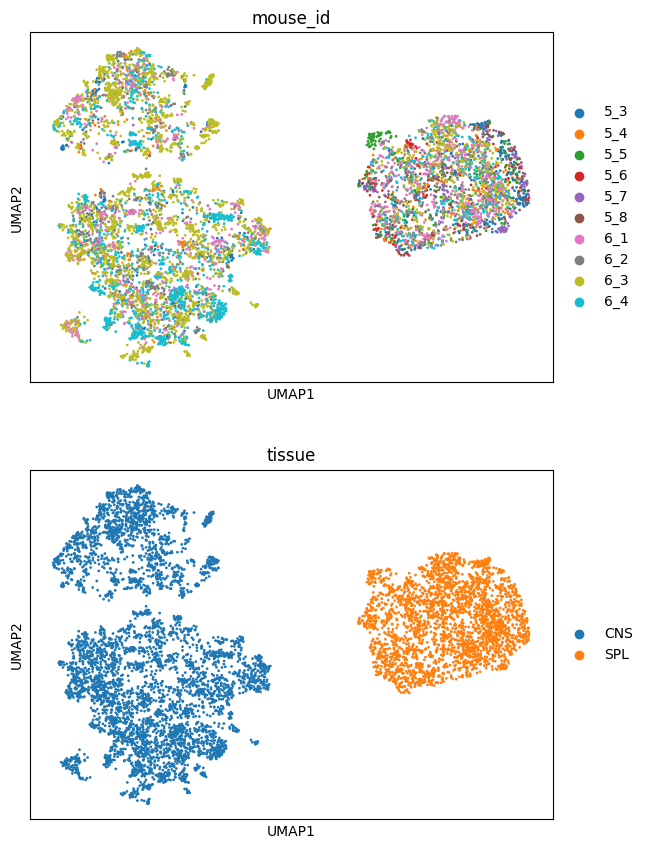

In [38]:
# PCA and neighbors computation
# sc.pp.pca(latent_sub, svd_solver="arpack", n_comps=50)
sc.pp.neighbors(latent_sub, use_rep='X', n_neighbors = 50)

# UMAP computation using umap.UMAP() directly
umap_model = umap.UMAP(
    min_dist=0.5,
    spread=1.0,
    random_state=42,
    n_neighbors=15,  # Default UMAP n_neighbors
    metric='euclidean'
)
latent_sub.obsm['X_umap'] = umap_model.fit_transform(latent_sub.X)

# legend_loc=None
sc.pl.umap(latent_sub, color=['mouse_id', 'tissue'], ncols=1, )


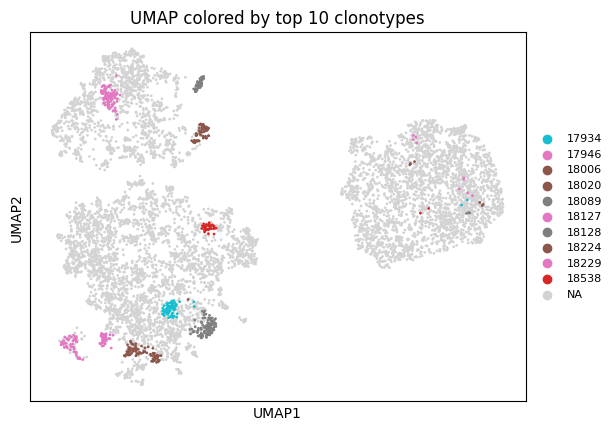

In [39]:
# Find top 10 clonotypes with largest clonotype_size
import seaborn as sns
top_clonotypes = latent_moe.obs.groupby('clonotype')['clonotype_size'].first().nlargest(10)

top_clonotype_list = top_clonotypes.index.tolist()

sc.pl.umap(latent_sub, color='clonotype', 
           groups=top_clonotype_list,  # Only show top clonotypes
           legend_loc='right margin',
           legend_fontsize=8,
           palette = sns.color_palette("tab10", 10).as_hex(),
           title='UMAP colored by top 10 clonotypes')



## Save UMAP and predict with KNN

In [40]:
# Save the trained UMAP model for future use
import joblib
import os

# Create models directory if it doesn't exist
models_dir = './saved_models/umap_models'
os.makedirs(models_dir, exist_ok=True)

# Save the UMAP model
umap_model_path = os.path.join(models_dir, 'umap_model_fitted.pkl')
joblib.dump(umap_model, umap_model_path)


['./saved_models/umap_models/umap_model_fitted.pkl']

In [41]:
# Example: How to load the saved UMAP model for future use
def load_umap_model(model_path='./saved_models/umap_models/umap_model_fitted.pkl'):
    import joblib
    import os
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"UMAP model not found at {model_path}")
    
    umap_model = joblib.load(model_path)
    
    return umap_model

# Example usage:
# loaded_umap_model = load_umap_model()
# new_umap_coords = loaded_umap_model.transform(new_pca_data)


In [46]:
# Map single cells to the UMAP using umap.UMAP() transform
# Query 
latent_query = model.get_latent(adata_test, metadata=[], return_mean=True, copy_adata_obs=True)

# Apply PCA to single cells using the same parameters
# sc.pp.pca(latent_query, svd_solver="arpack", n_comps=50)

# Transform single cells using the fitted UMAP model
# latent_query.obsm['X_umap'] = umap_model.transform(latent_query.obsm['X_pca'])

#  Have feature < PCA numbers
latent_query.obsm['X_umap'] = umap_model.transform(latent_query.X)


In [47]:
# Manual tissue mapping using k-NN classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

# Prepare training data (latent_sub with known tissue labels)
X_train = latent_sub.obsm['X_umap']
y_train = latent_sub.obs['tissue'].values

# Encode tissue labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# Train k-NN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train_encoded)

# Predict tissue for single cells
latent_query_EAE = latent_query[latent_query.obs['tissue'].isin(['CNS','SPL'])]

X_test = latent_query.obsm['X_umap']
y_pred_encoded = knn.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

# Add predicted tissue to single cells
latent_query.obs['predicted_tissue'] = y_pred


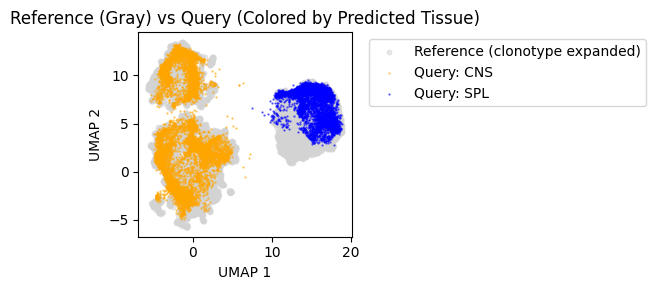

In [48]:
import matplotlib.pyplot as plt
# Combine data for visualization
combined_data = latent_sub.copy()
# Plot reference data in gray and query data with predicted tissue colors
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 3))


# Plot 1: Reference (clonotype expanded) in gray, query (single cells) colored by predicted tissue
ax1.scatter(combined_data.obsm['X_umap'][:, 0], combined_data.obsm['X_umap'][:, 1], 
           c='lightgray', s=10, alpha=0.5, label='Reference (clonotype expanded)')
y_train_encoded = le.fit_transform(y_train)

# Get unique tissues and create color map
tissues = latent_query.obs['predicted_tissue'].unique()
colors = ['orange', 'blue']
tissue_colors = dict(zip(tissues, colors))

for tissue in tissues:
    mask = latent_query.obs['predicted_tissue'] == tissue
    ax1.scatter(latent_query.obsm['X_umap'][mask, 0], latent_query.obsm['X_umap'][mask, 1],
               c=[tissue_colors[tissue]], s=0.4, alpha=0.6, label=f'Query: {tissue}')

ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.set_title('Reference (Gray) vs Query (Colored by Predicted Tissue)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Note, that the latent representation is highly separated to small clusters, that are mainly formed by one clonotype. This is due to the limited computational time (n_epochs, n_samples) spent to train these models in this tutorial.

In [49]:
# Calculate F-score for tissue prediction
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# Evaluate k-NN classifier on reference data
X_ref = latent_sub.obsm['X_umap']
y_ref = latent_sub.obs['tissue'].values

# Encode tissue labels
le_ref = LabelEncoder()
y_ref_encoded = le_ref.fit_transform(y_ref)

# Train/test split
X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(
    X_ref, y_ref_encoded, test_size=0.2, random_state=42, stratify=y_ref_encoded
)

# Train and predict
knn_cv = KNeighborsClassifier(n_neighbors=5)
knn_cv.fit(X_train_cv, y_train_cv)
y_pred_cv = knn_cv.predict(X_test_cv)

# Calculate F1-score
f1_weighted = f1_score(y_test_cv, y_pred_cv, average='weighted')

print(f"F1-score (weighted): {f1_weighted:.4f}")
print(f"Predicted {len(latent_query)} single cells")
print(f"Tissue distribution: {latent_query.obs['predicted_tissue'].value_counts().to_dict()}")


F1-score (weighted): 1.0000
Predicted 15025 single cells
Tissue distribution: {'CNS': 10133, 'SPL': 4892}
